# CodeAlpha — Exploratory Data Analysis

## Task 2: Book Dataset Analysis

This project performs Exploratory Data Analysis (EDA) on a book dataset
collected through web scraping.

### Objectives
- Understand the structure of the dataset
- Identify missing and duplicate data
- Analyze book prices and ratings
- Detect potential outliers
- Identify trends and patterns
- Visualize important findings
- Generate meaningful insights from the data

In [1]:
import os

print(os.getcwd())
print(os.listdir())

/home/cbit/CodeAlpha_WebScraping/Task2_EDA
['README.md', 'eda.ipynb', 'books_dataset.csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

/home/cbit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Libraries imported successfully!


In [5]:
import pandas as pd

df = pd.read_csv("books_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Number of rows: 20
Number of columns: 4


,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [6]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

Column Names:
['Title', 'Price', 'Availability', 'Rating']

Data Types:
Title            object
Price           float64
Availability     object
Rating           object
dtype: object

Dataset Shape:
(20, 4)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         20 non-null     object 
 1   Price         20 non-null     float64
 2   Availability  20 non-null     object 
 3   Rating        20 non-null     object 
dtypes: float64(1), object(3)
memory usage: 768.0+ bytes


In [8]:
df.describe()

,Price
count,20.000000
mean,38.048500
std,15.135231
min,13.990000
25%,22.637500
50%,41.380000
75%,51.865000
max,57.250000


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64


In [10]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [11]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Number"] = df["Rating"].map(rating_map)

df.head()

,Title,Price,Availability,Rating,Rating_Number
0,A Light in the Attic,51.77,In stock,Three,3
1,Tipping the Velvet,53.74,In stock,One,1
2,Soumission,50.10,In stock,One,1
3,Sharp Objects,47.82,In stock,Four,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,5


In [12]:
print("PRICE ANALYSIS")
print("=" * 40)

print(f"Minimum Price: £{df['Price'].min():.2f}")
print(f"Maximum Price: £{df['Price'].max():.2f}")
print(f"Average Price: £{df['Price'].mean():.2f}")
print(f"Median Price: £{df['Price'].median():.2f}")

PRICE ANALYSIS
Minimum Price: £13.99
Maximum Price: £57.25
Average Price: £38.05
Median Price: £41.38


In [13]:
print("TOP 5 MOST EXPENSIVE BOOKS")

df.nlargest(5, "Price")[["Title", "Price", "Rating"]]

TOP 5 MOST EXPENSIVE BOOKS


,Title,Price,Rating
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three
4,Sapiens: A Brief History of Humankind,54.23,Five
1,Tipping the Velvet,53.74,One
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five
9,The Black Maria,52.15,One


In [14]:
print("TOP 5 CHEAPEST BOOKS")

df.nsmallest(5, "Price")[["Title", "Price", "Rating"]]

TOP 5 CHEAPEST BOOKS


,Title,Price,Rating
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,Two
12,Set Me Free,17.46,Five
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three
11,Shakespeare's Sonnets,20.66,Four
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four


In [15]:
rating_order = ["One", "Two", "Three", "Four", "Five"]

rating_counts = (
    df["Rating"]
    .value_counts()
    .reindex(rating_order, fill_value=0)
)

print("RATING DISTRIBUTION")
print(rating_counts)

print("\nMost common rating:", rating_counts.idxmax())

RATING DISTRIBUTION
Rating
One      6
Two      3
Three    3
Four     4
Five     4
Name: count, dtype: int64

Most common rating: One


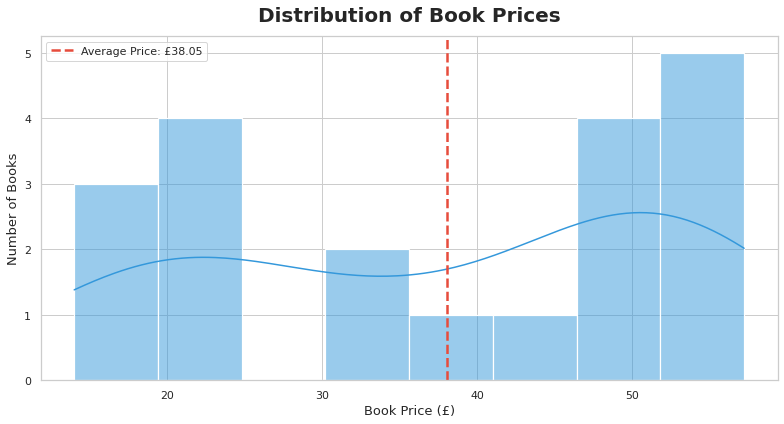

In [16]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x="Price",
    bins=8,
    kde=True,
    color="#3498DB",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    df["Price"].mean(),
    color="#E74C3C",
    linestyle="--",
    linewidth=2.5,
    label=f"Average Price: £{df['Price'].mean():.2f}"
)

plt.title(
    "Distribution of Book Prices",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Book Price (£)", fontsize=13)
plt.ylabel("Number of Books", fontsize=13)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

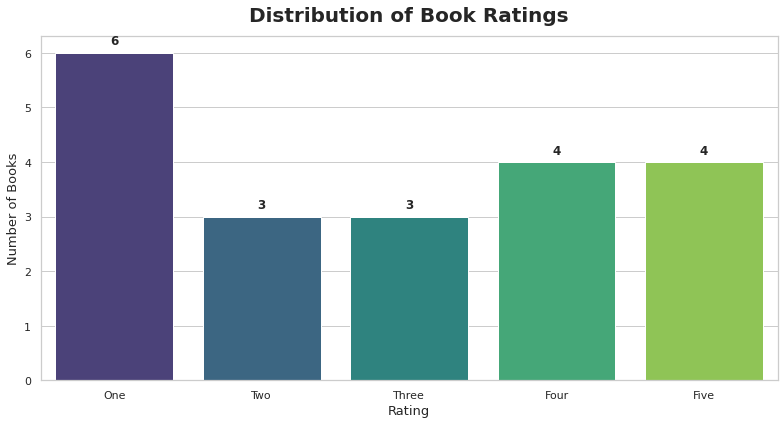

In [17]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    hue=rating_counts.index,
    palette="viridis",
    legend=False
)

for i, value in enumerate(rating_counts.values):
    ax.text(
        i,
        value + 0.15,
        str(value),
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Distribution of Book Ratings",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rating", fontsize=13)
plt.ylabel("Number of Books", fontsize=13)

plt.tight_layout()

plt.show()

In [18]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_limit) |
    (df["Price"] > upper_limit)
]

print("OUTLIER ANALYSIS")
print("=" * 40)

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Lower limit: £{lower_limit:.2f}")
print(f"Upper limit: £{upper_limit:.2f}")

print("\nPotential outliers:", len(outliers))

if len(outliers) > 0:
    display(outliers[["Title", "Price", "Rating"]])
else:
    print("No potential price outliers detected.")

OUTLIER ANALYSIS
Q1: £22.64
Q3: £51.87
IQR: £29.23
Lower limit: £-21.20
Upper limit: £95.71

Potential outliers: 0
No potential price outliers detected.


In [19]:

average_price_by_rating = (
    df.groupby("Rating_Number")["Price"]
    .mean()
    .round(2)
)

print("AVERAGE PRICE BY RATING")
print(average_price_by_rating)




AVERAGE PRICE BY RATING
Rating_Number
1    40.02
2    36.83
3    42.32
4    31.10
5    39.75
Name: Price, dtype: float64


Price-Rating Correlation: -0.076


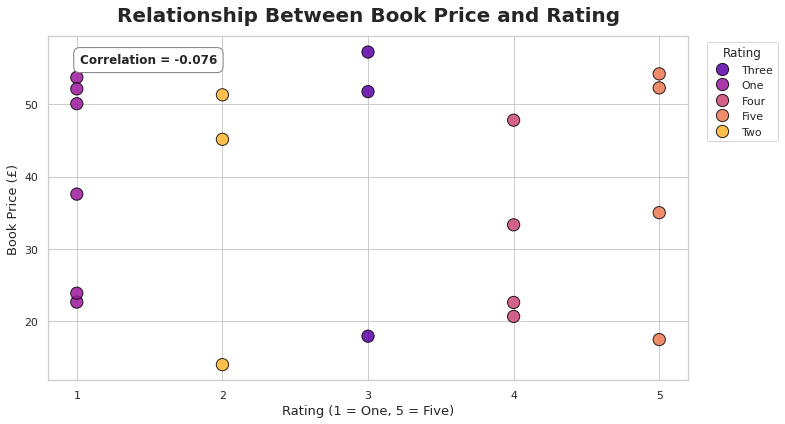

In [20]:
# Calculate correlation between Price and Rating
correlation = df["Price"].corr(df["Rating_Number"])

print(f"Price-Rating Correlation: {correlation:.3f}")

# Create professional scatter plot
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="Rating_Number",
    y="Price",
    hue="Rating",
    palette="plasma",
    s=150,
    alpha=0.85,
    edgecolor="black"
)

plt.title(
    "Relationship Between Book Price and Rating",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rating (1 = One, 5 = Five)", fontsize=13)
plt.ylabel("Book Price (£)", fontsize=13)

plt.xticks([1, 2, 3, 4, 5])

plt.legend(
    title="Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.text(
    0.05,
    0.95,
    f"Correlation = {correlation:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)

plt.tight_layout()
plt.show()

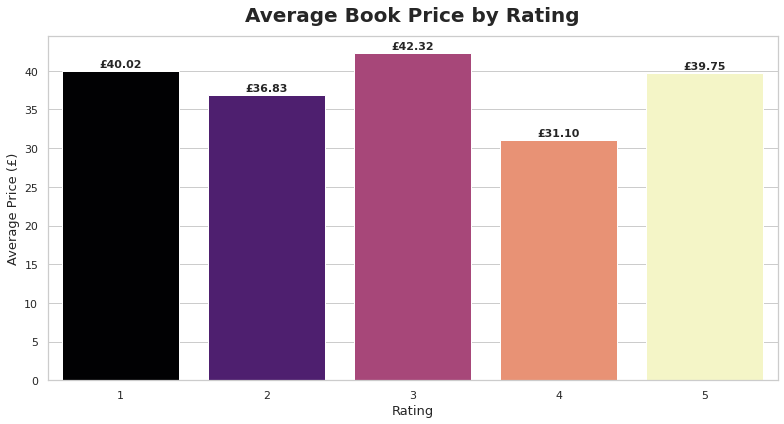

In [21]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=average_price_by_rating.index,
    y=average_price_by_rating.values,
    hue=average_price_by_rating.index,
    palette="magma",
    legend=False
)

for i, value in enumerate(average_price_by_rating.values):
    ax.text(
        i,
        value + 0.5,
        f"£{value:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Book Price by Rating",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rating", fontsize=13)
plt.ylabel("Average Price (£)", fontsize=13)

plt.tight_layout()

plt.show()

# Key Findings

Based on the Exploratory Data Analysis, the following findings were identified:

### 💰 Price Analysis
- The average book price is **£38.05**.
- The median book price is **£41.38**.
- The cheapest book costs **£13.99**.
- The most expensive book costs **£57.25**.
- Book prices show considerable variation across the dataset.

### ⭐ Rating Analysis
- The most common rating is **One**, with **6 books**.
- **Four** and **Five** ratings each occur for **4 books**.
- **Two** and **Three** ratings each occur for **3 books**.

### 🚨 Data Quality
- The dataset contains **20 records** and **4 original variables**.
- There are **no missing values**.
- There are **no duplicate records**.
- All 20 books are marked as **In stock**.

### 📦 Outlier Analysis
- The IQR method identified **0 potential price outliers**.
- Therefore, no unusually high or low book prices were detected using this method.

### 📊 Price and Rating
- The average price differs across rating groups.
- Books with a rating of **Three** have the highest average price at **£42.32**.
- Books with a rating of **Four** have the lowest average price at **£31.10**.
- This suggests that a higher rating does not necessarily mean a higher book price.

## ✅ Conclusion

The Exploratory Data Analysis provided an overview of the book dataset
and revealed useful patterns in book prices and ratings.

The dataset is clean, containing no missing values or duplicate records.
Book prices range from **£13.99 to £57.25**, with an average price of
approximately **£38.05**.

The rating distribution shows that **One** is the most frequently occurring
rating in the dataset. The analysis also found no potential price outliers
using the IQR method.

The comparison of prices across rating groups indicates that book ratings
and prices do not follow a simple increasing relationship. Overall, the EDA
provides a useful foundation for further data visualization and analysis.